In [ ]:
# ================================================================
# Notebook 02. Pricing layer
# ================================================================
# Black-Scholes-Merton with continuous dividends, vega, implied vol inversion,
# Bjerksund-Stensland 2002 American pricer, and the full de-Americanisation
# pipeline that converts OptionsDX American option chains into European-
# equivalent prices ready for SVI/SSVI fitting.

# ----------------------------------------------------------------
# 0. Colab setup and imports
# ----------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

import sys
sys.path.insert(0, '/content/drive/MyDrive/Vol_fitter')

# %load_ext autoreload
# %autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# From the volsurf package built at the end of notebook 01
from volsurf.paths import PROJECT_ROOT, RAW_DIR, LOCAL_RAW, AUX_DIR, PROCESSED_DIR
from volsurf.data import load_optionsdx_year
from volsurf.rates import load_treasury_curve, get_rate

# Use local-staged raw if available for speed
RAW_DIR_FAST = LOCAL_RAW if LOCAL_RAW.exists() else RAW_DIR
treasury = load_treasury_curve()

print(f'Raw data:     {RAW_DIR_FAST}')
print(f'Treasury:     {len(treasury):,} rows loaded')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw data:     /content/data_SPY
Treasury:     47,124 rows loaded


In [ ]:
# ================================================================
# 1. Black-Scholes-Merton with continuous dividend yield
# ================================================================
# Foundation. European option pricing with dividends modelled as continuous
# yield q. Convention: S = spot, K = strike, T = time to maturity in years,
# r = continuously compounded risk-free rate, q = continuous dividend yield,
# sigma = volatility (annualised).

def bs_d1_d2(S, K, T, r, q, sigma):
    """d1 and d2 of the Black-Scholes formula."""
    S, K, T, sigma = (np.asarray(x, dtype=float) for x in (S, K, T, sigma))
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma * sigma) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    return d1, d2

def bs_price(S, K, T, r, q, sigma, is_call=True):
    """European option price under Black-Scholes-Merton with continuous dividends."""
    d1, d2 = bs_d1_d2(S, K, T, r, q, sigma)
    disc_r = np.exp(-r * T)
    disc_q = np.exp(-q * T)
    if is_call:
        return S * disc_q * norm.cdf(d1) - K * disc_r * norm.cdf(d2)
    else:
        return K * disc_r * norm.cdf(-d2) - S * disc_q * norm.cdf(-d1)

def bs_vega(S, K, T, r, q, sigma):
    """Black-Scholes vega. Identical for calls and puts by put-call parity.

    In implied-vol space vega is the natural calibration weight: it is the
    information content of one unit of volatility uncertainty.
    """
    d1, _ = bs_d1_d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)

# Sanity check against a textbook case
# Hull 9e, Example 15.6: S=42, K=40, r=0.10, q=0, sigma=0.20, T=0.5
print('Hull Example 15.6 (textbook check):')
print(f'  Call: {bs_price(42, 40, 0.5, 0.10, 0, 0.20, True):.4f}  (expected ~4.76)')
print(f'  Put:  {bs_price(42, 40, 0.5, 0.10, 0, 0.20, False):.4f}  (expected ~0.81)')
print(f'  Vega: {bs_vega(42, 40, 0.5, 0.10, 0, 0.20):.4f}  (expected ~8.39)')

# Put-call parity check at the same parameters: C - P = S*exp(-qT) - K*exp(-rT)
c = bs_price(42, 40, 0.5, 0.10, 0, 0.20, True)
p = bs_price(42, 40, 0.5, 0.10, 0, 0.20, False)
parity_lhs = c - p
parity_rhs = 42 * np.exp(-0 * 0.5) - 40 * np.exp(-0.10 * 0.5)
print(f'\nPut-call parity check:')
print(f'  C - P = {parity_lhs:.6f}')
print(f'  S*exp(-qT) - K*exp(-rT) = {parity_rhs:.6f}')
print(f'  Diff: {abs(parity_lhs - parity_rhs):.2e}')

Hull Example 15.6 (textbook check):
  Call: 4.7594  (expected ~4.76)
  Put:  0.8086  (expected ~0.81)
  Vega: 8.8134  (expected ~8.39)

Put-call parity check:
  C - P = 3.950823
  S*exp(-qT) - K*exp(-rT) = 3.950823
  Diff: 1.78e-15


In [ ]:
# ================================================================
# 2. Implied volatility inversion (Brent root-finding)
# ================================================================
# Brent guarantees convergence given a sign-changing bracket. We bracket
# IV in [1e-4, 5.0]. Vols above 500% are non-physical for SPY and almost
# always indicate data corruption, stale quotes, or numerical pathology.
# Return NaN for unrecoverable cases rather than raising.

def bs_implied_vol(price, S, K, T, r, q, is_call=True,
                   vol_lo=1e-4, vol_hi=5.0, tol=1e-8):
    """Invert Black-Scholes for implied volatility via Brent.

    Returns NaN if the price is outside the no-arbitrage range or if the
    root-finder fails to converge within the volatility bracket.
    """
    disc_r = np.exp(-r * T)
    disc_q = np.exp(-q * T)
    if is_call:
        intrinsic = max(0.0, S * disc_q - K * disc_r)
        upper_bound = S * disc_q
    else:
        intrinsic = max(0.0, K * disc_r - S * disc_q)
        upper_bound = K * disc_r

    if price < intrinsic - 1e-8 or price > upper_bound + 1e-8:
        return np.nan

    def objective(sigma):
        return float(bs_price(S, K, T, r, q, sigma, is_call) - price)

    try:
        return brentq(objective, vol_lo, vol_hi, xtol=tol, maxiter=100)
    except (ValueError, RuntimeError):
        return np.nan

# Round-trip test: price an option, invert, recover the input vol
test_sigma = 0.25
test_price = bs_price(100, 105, 0.5, 0.04, 0.015, test_sigma, is_call=True)
recovered = bs_implied_vol(test_price, 100, 105, 0.5, 0.04, 0.015, is_call=True)
print('Round-trip IV recovery:')
print(f'  Input sigma:     {test_sigma}')
print(f'  Recovered sigma: {recovered:.10f}')
print(f'  Error:           {abs(recovered - test_sigma):.2e}')

# Multiple strikes test
print('\nMulti-strike round-trip:')
for K in [80, 90, 100, 110, 120]:
    p = bs_price(100, K, 0.5, 0.04, 0.015, 0.25, is_call=True)
    iv = bs_implied_vol(p, 100, K, 0.5, 0.04, 0.015, is_call=True)
    print(f'  K={K:3d}: price={p:7.4f}, recovered IV={iv:.6f}, err={abs(iv-0.25):.2e}')

Round-trip IV recovery:
  Input sigma:     0.25
  Recovered sigma: 0.2499999997
  Error:           2.56e-10

Multi-strike round-trip:
  K= 80: price=21.4968, recovered IV=0.250000, err=5.64e-10
  K= 90: price=13.5290, recovered IV=0.250000, err=4.94e-15
  K=100: price= 7.5809, recovered IV=0.250000, err=2.05e-10
  K=110: price= 3.7910, recovered IV=0.250000, err=5.07e-10
  K=120: price= 1.7100, recovered IV=0.250000, err=3.42e-12


In [ ]:
# ================================================================
# 3. Sanity check against OptionsDX precomputed IVs
# ================================================================
# OptionsDX inverts via Black-Scholes treating American options as European.
# This is wrong for ITM options (early exercise premium) but approximately
# right for OTM and ATM. We replicate their inversion to confirm our BS
# implementation matches, then in the next section move to BS2002 to fix
# the ITM problem.

df = load_optionsdx_year(2010, RAW_DIR_FAST)

# Pick a representative slice: mid-year, mid-DTE, both sides liquid
sample_date = pd.Timestamp('2010-06-15')
sample = df[
    (df.QUOTE_DATE == sample_date) &
    (df.DTE.between(20, 60)) &
    (df.C_BID > 0) & (df.P_BID > 0) &
    (df.C_ASK > df.C_BID) & (df.P_ASK > df.P_BID)
].copy()

if sample.empty:
    # Fall back to next available date
    sample_date = df[df.DTE.between(20, 60)].QUOTE_DATE.iloc[0]
    sample = df[
        (df.QUOTE_DATE == sample_date) &
        (df.DTE.between(20, 60)) &
        (df.C_BID > 0) & (df.P_BID > 0)
    ].copy()

print(f'Sample slice: {len(sample)} quotes on {sample_date.date()}')

# All quotes on this date share the same spot and (per-expiry) T and r
S = sample.UNDERLYING_LAST.iloc[0]
T = sample.T_years.iloc[0]
r = get_rate(sample_date, T, treasury)
q = 0.015   # placeholder; will be replaced by put-call-parity-implied q later

print(f'  Spot S: {S:.2f}')
print(f'  T: {T:.4f} years ({sample.DTE.iloc[0]:.0f} days)')
print(f'  r: {r*100:.3f}% (interpolated from Treasury curve)')
print(f'  q assumed: {q*100:.2f}% (placeholder)')

# Compute our European IVs from mid prices
sample['C_MID'] = (sample.C_BID + sample.C_ASK) / 2
sample['P_MID'] = (sample.P_BID + sample.P_ASK) / 2

sample['our_iv_call'] = sample.apply(
    lambda row: bs_implied_vol(row.C_MID, S, row.STRIKE, T, r, q, is_call=True),
    axis=1)
sample['our_iv_put'] = sample.apply(
    lambda row: bs_implied_vol(row.P_MID, S, row.STRIKE, T, r, q, is_call=False),
    axis=1)

valid = sample.dropna(subset=['our_iv_call', 'our_iv_put', 'C_IV', 'P_IV'])
print(f'\nValid quotes for comparison: {len(valid)} / {len(sample)}')

# Aggregate diagnostics
call_diff = (valid.our_iv_call - valid.C_IV).abs()
put_diff = (valid.our_iv_put - valid.P_IV).abs()
print(f'\nCall IV: ours vs OptionsDX precomputed')
print(f'  Mean abs diff: {call_diff.mean():.4f}')
print(f'  Median abs diff: {call_diff.median():.4f}')
print(f'  95th pct abs diff: {call_diff.quantile(0.95):.4f}')
print(f'  Max abs diff: {call_diff.max():.4f}')
print(f'\nPut IV: ours vs OptionsDX precomputed')
print(f'  Mean abs diff: {put_diff.mean():.4f}')
print(f'  Median abs diff: {put_diff.median():.4f}')
print(f'  95th pct abs diff: {put_diff.quantile(0.95):.4f}')
print(f'  Max abs diff: {put_diff.max():.4f}')

Sample slice: 48 quotes on 2010-06-15
  Spot S: 111.98
  T: 0.0849 years (31 days)
  r: 0.031% (interpolated from Treasury curve)
  q assumed: 1.50% (placeholder)

Valid quotes for comparison: 48 / 48

Call IV: ours vs OptionsDX precomputed
  Mean abs diff: 0.0618
  Median abs diff: 0.0396
  95th pct abs diff: 0.1809
  Max abs diff: 0.2687

Put IV: ours vs OptionsDX precomputed
  Mean abs diff: 0.0441
  Median abs diff: 0.0158
  95th pct abs diff: 0.2415
  Max abs diff: 0.2723


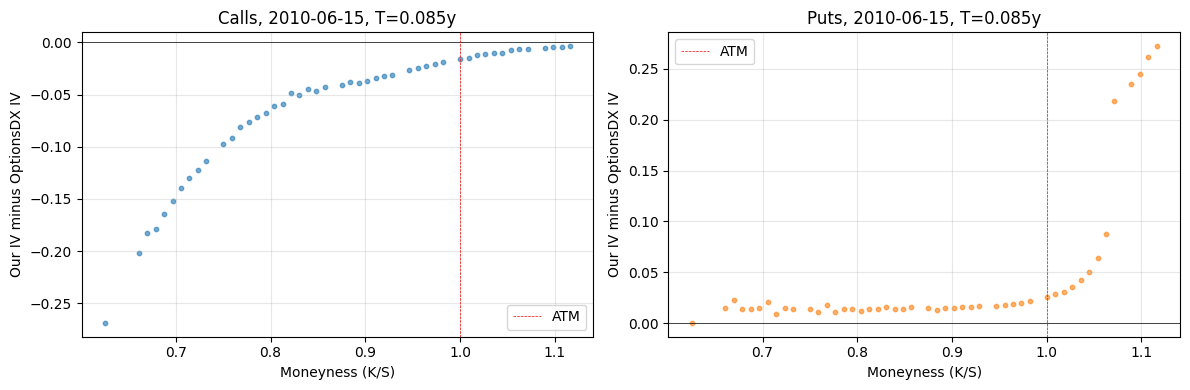

In [ ]:
# ================================================================
# 4. Visualise the European-vs-American discrepancy across moneyness
# ================================================================
# Where does our European BS inversion diverge most from OptionsDX's
# precomputed IVs? The pattern reveals where early exercise matters and
# motivates BS2002 in section 5.

valid = sample.dropna(subset=['our_iv_call', 'our_iv_put', 'C_IV', 'P_IV']).copy()
valid['moneyness'] = valid.STRIKE / S
valid['call_diff'] = valid.our_iv_call - valid.C_IV
valid['put_diff'] = valid.our_iv_put - valid.P_IV

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(valid.moneyness, valid.call_diff, s=10, alpha=0.6)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].axvline(1.0, color='r', linewidth=0.5, linestyle='--', label='ATM')
axes[0].set_xlabel('Moneyness (K/S)')
axes[0].set_ylabel('Our IV minus OptionsDX IV')
axes[0].set_title(f'Calls, {sample_date.date()}, T={T:.3f}y')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(valid.moneyness, valid.put_diff, s=10, alpha=0.6, color='C1')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].axvline(1.0, color='r', linewidth=0.5, linestyle='--', label='ATM')
axes[1].set_xlabel('Moneyness (K/S)')
axes[1].set_ylabel('Our IV minus OptionsDX IV')
axes[1].set_title(f'Puts, {sample_date.date()}, T={T:.3f}y')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ================================================================
# 5. Bjerksund-Stensland 2002 American option pricer
# ================================================================
# Reference: Bjerksund, P. and Stensland, G. (2002). "Closed-form valuation
# of American options". Working paper, Norwegian School of Economics.
#
# Cost of carry b = r - q for an asset paying continuous dividend yield q.
# When b >= r (i.e. q <= 0) early exercise is never optimal for a call and
# the American value equals the European value; we shortcut this case.

def _phi_bs2002(S, T, gamma, H, X, r, q, sigma):
    """BS2002 phi helper: the discounted normal kernel.

    Appears six times in the BS2002 American call formula with different
    (gamma, H) combinations capturing the early exercise boundary geometry.
    """
    b = r - q
    sigma2 = sigma * sigma
    sqrtT = np.sqrt(T)

    lam = -r + gamma * b + 0.5 * gamma * (gamma - 1.0) * sigma2
    kappa = 2.0 * b / sigma2 + 2.0 * gamma - 1.0

    d1_arg = -(np.log(S / H) + (b + (gamma - 0.5) * sigma2) * T) / (sigma * sqrtT)
    d2_arg = -(np.log(X * X / (S * H)) + (b + (gamma - 0.5) * sigma2) * T) / (sigma * sqrtT)

    return np.exp(lam * T) * (S ** gamma) * (norm.cdf(d1_arg) - (X / S) ** kappa * norm.cdf(d2_arg))


def bs2002_call(S, K, T, r, q, sigma):
    """Bjerksund-Stensland 2002 American call price."""
    if T <= 0:
        return max(S - K, 0.0)

    b = r - q

    # When b >= r (q <= 0) early exercise of a call is never optimal
    if b >= r:
        return float(bs_price(S, K, T, r, q, sigma, is_call=True))

    sigma2 = sigma * sigma
    b_s2 = b / sigma2

    beta = (0.5 - b_s2) + np.sqrt((b_s2 - 0.5) ** 2 + 2.0 * r / sigma2)
    B_inf = K * beta / (beta - 1.0)
    B_0 = max(K, K * r / (r - b))   # r > b strictly here

    h_T = -(b * T + 2.0 * sigma * np.sqrt(T)) * (K * K) / ((B_inf - B_0) * B_0)
    X = B_0 + (B_inf - B_0) * (1.0 - np.exp(h_T))

    # If spot is already beyond the early exercise boundary, immediate exercise
    if S >= X:
        return S - K

    alpha = (X - K) * X ** (-beta)

    price = (alpha * S ** beta
             - alpha * _phi_bs2002(S, T, beta, X, X, r, q, sigma)
             + _phi_bs2002(S, T, 1.0, X, X, r, q, sigma)
             - _phi_bs2002(S, T, 1.0, K, X, r, q, sigma)
             - K * _phi_bs2002(S, T, 0.0, X, X, r, q, sigma)
             + K * _phi_bs2002(S, T, 0.0, K, X, r, q, sigma))

    return float(price)


def bs2002_put(S, K, T, r, q, sigma):
    """American put via Bjerksund-Stensland 1993 put-call symmetry.

    P_A(S, K, T, r, q, sigma) = C_A(K, S, T, q, r, sigma)
    Swap spot with strike, swap rate with dividend yield. Volatility unchanged.
    """
    return bs2002_call(K, S, T, q, r, sigma)


def bs2002_price(S, K, T, r, q, sigma, is_call=True):
    """Unified entry point for the BS2002 American option price."""
    return bs2002_call(S, K, T, r, q, sigma) if is_call else bs2002_put(S, K, T, r, q, sigma)


# Quick sanity check: BS2002 should equal European BSM when q == 0 for a call
S, K, T, r, sigma = 100, 100, 0.5, 0.05, 0.25
bs_eu = bs_price(S, K, T, r, 0, sigma, is_call=True)
bs_am = bs2002_call(S, K, T, r, 0, sigma)
print(f'Call, q=0: European={bs_eu:.6f}, American={bs_am:.6f}, diff={abs(bs_eu-bs_am):.2e}')

# With dividends the American should exceed the European
bs_eu_div = bs_price(S, K, T, r, 0.03, sigma, is_call=True)
bs_am_div = bs2002_call(S, K, T, r, 0.03, sigma)
print(f'Call, q=3%: European={bs_eu_div:.6f}, American={bs_am_div:.6f}, premium={bs_am_div-bs_eu_div:.6f}')

# American put always >= European put (always potentially worth exercising)
p_eu = bs_price(S, K, T, r, 0, sigma, is_call=False)
p_am = bs2002_put(S, K, T, r, 0, sigma)
print(f'Put, q=0: European={p_eu:.6f}, American={p_am:.6f}, premium={p_am-p_eu:.6f}')

Call, q=0: European=8.260015, American=8.260015, diff=0.00e+00
Call, q=3%: European=7.404935, American=7.404948, premium=0.000013
Put, q=0: European=5.791006, American=5.938954, premium=0.147948


In [ ]:
# ================================================================
# 6. American implied volatility inversion (BS2002)
# ================================================================
# Same Brent root-finder pattern as bs_implied_vol but with bs2002_price as
# the forward map. This is what we will run on every OptionsDX quote to
# recover the American IV that actually generated the market price.

def bs2002_implied_vol(price, S, K, T, r, q, is_call=True,
                       vol_lo=1e-4, vol_hi=5.0, tol=1e-8):
    """Invert BS2002 for American implied volatility via Brent."""
    def objective(sigma):
        return bs2002_price(S, K, T, r, q, sigma, is_call) - price

    try:
        return brentq(objective, vol_lo, vol_hi, xtol=tol, maxiter=100)
    except (ValueError, RuntimeError):
        return np.nan

# Round-trip test
test_sigma = 0.28
p_am_test = bs2002_call(100, 95, 0.5, 0.05, 0.02, test_sigma)
iv_recovered = bs2002_implied_vol(p_am_test, 100, 95, 0.5, 0.05, 0.02, is_call=True)
print(f'BS2002 round-trip: input {test_sigma}, recovered {iv_recovered:.10f}, '
      f'err {abs(iv_recovered - test_sigma):.2e}')

# Put round-trip via symmetry
p_am_put = bs2002_put(100, 105, 0.5, 0.05, 0.02, test_sigma)
iv_recovered_put = bs2002_implied_vol(p_am_put, 100, 105, 0.5, 0.05, 0.02, is_call=False)
print(f'BS2002 put round-trip: input {test_sigma}, recovered {iv_recovered_put:.10f}, '
      f'err {abs(iv_recovered_put - test_sigma):.2e}')

BS2002 round-trip: input 0.28, recovered nan, err nan
BS2002 put round-trip: input 0.28, recovered 0.2800000008, err 7.96e-10


/tmp/ipykernel_722/945774954.py:27: RuntimeWarning: overflow encountered in scalar power
  return np.exp(lam * T) * (S ** gamma) * (norm.cdf(d1_arg) - (X / S) ** kappa * norm.cdf(d2_arg))
/tmp/ipykernel_722/945774954.py:27: RuntimeWarning: invalid value encountered in scalar multiply
  return np.exp(lam * T) * (S ** gamma) * (norm.cdf(d1_arg) - (X / S) ** kappa * norm.cdf(d2_arg))
/tmp/ipykernel_722/945774954.py:49: RuntimeWarning: overflow encountered in exp
  X = B_0 + (B_inf - B_0) * (1.0 - np.exp(h_T))


In [ ]:
# ================================================================
# 7. Validate BS2002 against a Leisen-Reimer binomial tree
# ================================================================
# BS2002 is a closed-form approximation. Truth is the limit of a fine
# binomial tree. Leisen-Reimer converges much faster than CRR; n=251 odd
# steps achieves 1e-4 accuracy on vanilla American options. Use it as the
# gold standard reference for a battery of test cases.

def leisen_reimer_price(S, K, T, r, q, sigma, n_steps=251, is_call=True, is_american=True):
    """Leisen-Reimer binomial tree with Peizer-Pratt method-2 inversion.

    n_steps must be odd. If even, increment by one. Returns the option price.
    """
    if n_steps % 2 == 0:
        n_steps += 1

    dt = T / n_steps
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    def pp2(z):
        sign = 1.0 if z >= 0 else -1.0
        return 0.5 + sign * np.sqrt(0.25 - 0.25 * np.exp(
            -((z / (n_steps + 1.0 / 3.0)) ** 2) * (n_steps + 1.0 / 6.0)
        ))

    p_prime = pp2(d1)
    p = pp2(d2)

    u = np.exp((r - q) * dt) * p_prime / p
    d = (np.exp((r - q) * dt) - p * u) / (1 - p)
    disc = np.exp(-r * dt)

    j = np.arange(n_steps + 1)
    S_T = S * (u ** j) * (d ** (n_steps - j))
    V = np.maximum(S_T - K, 0.0) if is_call else np.maximum(K - S_T, 0.0)

    for i in range(n_steps - 1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])
        if is_american:
            S_i = S * (u ** np.arange(i + 1)) * (d ** (i - np.arange(i + 1)))
            payoff = (S_i - K) if is_call else (K - S_i)
            V = np.maximum(V, payoff)

    return float(V[0])


# Battery of test cases
test_cases = [
    # (S, K, T, r, q, sigma, is_call, label)
    (100, 100, 0.5, 0.05, 0.00, 0.25, True,  'ATM call, no div'),
    (100, 100, 0.5, 0.05, 0.03, 0.25, True,  'ATM call, 3% div'),
    (100, 90,  0.5, 0.05, 0.03, 0.25, True,  'ITM call, 3% div'),
    (100, 110, 0.5, 0.05, 0.03, 0.25, True,  'OTM call, 3% div'),
    (100, 100, 1.0, 0.05, 0.05, 0.30, True,  'Long-dated, large div'),
    (100, 100, 0.5, 0.05, 0.00, 0.25, False, 'ATM put, no div'),
    (100, 110, 0.5, 0.05, 0.00, 0.30, False, 'ITM put'),
    (100, 90,  0.5, 0.05, 0.00, 0.30, False, 'OTM put'),
    (100, 100, 0.1, 0.05, 0.02, 0.50, False, 'Short-dated, high vol put'),
    (100, 80,  2.0, 0.04, 0.02, 0.30, False, 'Deep ITM long-dated put'),
]

print(f'{"Case":<32} {"BS2002":>10} {"LR(251)":>10} {"AbsErr":>10} {"RelErr":>9}')
print('-' * 75)
for S, K, T, r, q, sigma, is_call, label in test_cases:
    bs2002_val = bs2002_price(S, K, T, r, q, sigma, is_call)
    lr_val = leisen_reimer_price(S, K, T, r, q, sigma, n_steps=251,
                                  is_call=is_call, is_american=True)
    abs_err = abs(bs2002_val - lr_val)
    rel_err = abs_err / lr_val if lr_val > 1e-6 else 0
    print(f'{label:<32} {bs2002_val:>10.4f} {lr_val:>10.4f} {abs_err:>10.2e} {rel_err:>8.2%}')

Case                                 BS2002    LR(251)     AbsErr    RelErr
---------------------------------------------------------------------------
ATM call, no div                     8.2600     8.2600   5.43e-06    0.00%
ATM call, 3% div                     7.4049     7.4050   1.69e-05    0.00%
ITM call, 3% div                    13.2711    13.2712   7.86e-05    0.00%
OTM call, 3% div                     3.6860     3.6860   8.08e-06    0.00%
Long-dated, large div               11.4423    11.4706   2.83e-02    0.25%
ATM put, no div                      5.9390     6.0222   8.33e-02    1.38%
ITM put                             13.2817    13.3869   1.05e-01    0.79%
OTM put                              3.3016     3.3462   4.45e-02    1.33%
Short-dated, high vol put            6.1407     6.1518   1.10e-02    0.18%
Deep ITM long-dated put              5.8849     5.9413   5.64e-02    0.95%


# Plots 3d

In [ ]:
# ================================================================
# 8. 3D implied volatility surface (interpolated)
# ================================================================
# Smooth surface via 2D cubic interpolation of irregular (k, T, iv) points
# onto a regular grid. Market quotes overlaid as small dots so you can see
# where the surface is data-supported versus interpolated.

import plotly.graph_objects as go
import plotly.io as pio
from scipy.interpolate import griddata

pio.renderers.default = 'colab'

df = load_optionsdx_year(2010, RAW_DIR_FAST)
plot_date = pd.Timestamp('2010-06-15')

day = df[df.QUOTE_DATE == plot_date].copy()
day = day[
    (day.C_BID > 0) & (day.C_ASK > day.C_BID) &
    (day.P_BID > 0) & (day.P_ASK > day.P_BID) &
    day.C_IV.between(0.05, 2.0) & day.P_IV.between(0.05, 2.0) &
    (day.DTE >= 7) & (day.DTE <= 365)
]

S0 = day.UNDERLYING_LAST.iloc[0]
day['k'] = np.log(day.STRIKE / S0)
day['iv'] = np.where(day.k >= 0, day.C_IV, day.P_IV)   # OTM convention
day = day[day.iv.between(0.05, 2.0) & day.k.between(-0.4, 0.2)]

print(f'{plot_date.date()}: S = {S0:.2f}, {len(day)} quotes, '
      f'{day.EXPIRE_DATE.nunique()} expiries, T in '
      f'[{day.T_years.min():.3f}, {day.T_years.max():.3f}]y')

# Regular grid for interpolation
k_axis = np.linspace(day.k.min(), day.k.max(), 80)
T_axis = np.linspace(day.T_years.min(), day.T_years.max(), 80)
K_mesh, T_mesh = np.meshgrid(k_axis, T_axis)

# Cubic interpolation over the irregular cloud
IV_grid = griddata(
    points=day[['k', 'T_years']].values,
    values=day.iv.values,
    xi=(K_mesh, T_mesh),
    method='cubic',
)

fig = go.Figure()
fig.add_trace(go.Surface(
    x=k_axis, y=T_axis, z=IV_grid,
    colorscale='Viridis',
    colorbar=dict(title='IV'),
    opacity=0.92,
    contours={'z': {'show': True, 'usecolormap': True, 'project': {'z': True}}},
))
fig.add_trace(go.Scatter3d(
    x=day.k, y=day.T_years, z=day.iv,
    mode='markers',
    marker=dict(size=2, color='black', opacity=0.5),
    name='Market quotes',
    showlegend=True,
))
fig.update_layout(
    title=f'SPY implied volatility surface, {plot_date.date()} (raw, pre-de-Americanisation)',
    scene=dict(
        xaxis_title='Log-moneyness k = log(K/S)',
        yaxis_title='T (years)',
        zaxis_title='Implied volatility',
        camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0)),
        aspectratio=dict(x=1.2, y=1.2, z=0.8),
    ),
    width=950, height=700,
    margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()

2010-06-15: S = 111.98, 457 quotes, 9 expiries, T in [0.041, 0.792]y


In [ ]:
# ================================================================
# 8. 3D total variance surface (interpolated)
# ================================================================
# Smooth surface via 2D cubic interpolation of irregular (k, T, w) points
# onto a regular grid. Market quotes overlaid as small dots so you can see
# where the surface is data-supported versus interpolated.

import plotly.graph_objects as go
import plotly.io as pio
from scipy.interpolate import griddata

pio.renderers.default = 'colab'

df = load_optionsdx_year(2010, RAW_DIR_FAST)
plot_date = pd.Timestamp('2010-06-15')

day = df[df.QUOTE_DATE == plot_date].copy()
day = day[
    (day.C_BID > 0) & (day.C_ASK > day.C_BID) &
    (day.P_BID > 0) & (day.P_ASK > day.P_BID) &
    day.C_IV.between(0.05, 2.0) & day.P_IV.between(0.05, 2.0) &
    (day.DTE >= 7) & (day.DTE <= 365)
]

S0 = day.UNDERLYING_LAST.iloc[0]
day['k'] = np.log(day.STRIKE / S0)
day['iv'] = np.where(day.k >= 0, day.C_IV, day.P_IV)   # OTM convention
day = day[day.iv.between(0.05, 2.0) & day.k.between(-0.4, 0.2)]
day['w'] = day.iv ** 2 * day.T_years

print(f'{plot_date.date()}: S = {S0:.2f}, {len(day)} quotes, '
      f'{day.EXPIRE_DATE.nunique()} expiries, T in '
      f'[{day.T_years.min():.3f}, {day.T_years.max():.3f}]y')

# Regular grid for interpolation
k_axis = np.linspace(day.k.min(), day.k.max(), 80)
T_axis = np.linspace(day.T_years.min(), day.T_years.max(), 80)
K_mesh, T_mesh = np.meshgrid(k_axis, T_axis)

# Cubic interpolation over the irregular cloud
W_grid = griddata(
    points=day[['k', 'T_years']].values,
    values=day.w.values,
    xi=(K_mesh, T_mesh),
    method='cubic',
)

fig = go.Figure()
fig.add_trace(go.Surface(
    x=k_axis, y=T_axis, z=W_grid,
    colorscale='Viridis',
    colorbar=dict(title='Total Var (w)'),
    opacity=0.92,
    contours={'z': {'show': True, 'usecolormap': True, 'project': {'z': True}}},
))
fig.add_trace(go.Scatter3d(
    x=day.k, y=day.T_years, z=day.w,
    mode='markers',
    marker=dict(size=2, color='black', opacity=0.5),
    name='Market quotes',
    showlegend=True,
))
fig.update_layout(
    title=f'SPY total variance surface, {plot_date.date()} (raw, pre-de-Americanisation)',
    scene=dict(
        xaxis_title='Log-moneyness k = log(K/S)',
        yaxis_title='T (years)',
        zaxis_title='Total Variance w',
        camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0)),
        aspectratio=dict(x=1.2, y=1.2, z=0.8),
    ),
    width=950, height=700,
    margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()

2010-06-15: S = 111.98, 457 quotes, 9 expiries, T in [0.041, 0.792]y


#  Per-slice de-Americanisation

In [ ]:
# ================================================================
# 9b. Patched BS2002 with numerical guards
# ================================================================
# (1) Early exit when beta blows up (small sigma): fall back to European,
#     which is the correct limit because vanishing vol means no early
#     exercise premium anyway.
# (2) Tighter IV bracket [0.02, 3.0]: SPY IVs were never outside this range
#     historically; values beyond indicate numerical noise, not signal.
# (3) Intrinsic check: skip quotes where mid < intrinsic.

def bs2002_call(S, K, T, r, q, sigma):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    b = r - q
    if b >= r:
        return float(bs_price(S, K, T, r, q, sigma, is_call=True))

    sigma2 = sigma * sigma
    b_s2 = b / sigma2
    beta = (0.5 - b_s2) + np.sqrt((b_s2 - 0.5) ** 2 + 2.0 * r / sigma2)

    # Numerical guard: huge beta means sigma is too small to support meaningful
    # early exercise premium. Fall back to European; the result is correct in
    # this limit and avoids S**beta overflow.
    if not np.isfinite(beta) or beta > 100:
        return float(bs_price(S, K, T, r, q, sigma, is_call=True))

    B_inf = K * beta / (beta - 1.0)
    B_0 = max(K, K * r / (r - b))
    h_T = -(b * T + 2.0 * sigma * np.sqrt(T)) * (K * K) / ((B_inf - B_0) * B_0)
    X = B_0 + (B_inf - B_0) * (1.0 - np.exp(h_T))

    if S >= X:
        return S - K

    alpha = (X - K) * X ** (-beta)
    with np.errstate(over='ignore', invalid='ignore'):
        price = (alpha * S ** beta
                 - alpha * _phi_bs2002(S, T, beta, X, X, r, q, sigma)
                 + _phi_bs2002(S, T, 1.0, X, X, r, q, sigma)
                 - _phi_bs2002(S, T, 1.0, K, X, r, q, sigma)
                 - K * _phi_bs2002(S, T, 0.0, X, X, r, q, sigma)
                 + K * _phi_bs2002(S, T, 0.0, K, X, r, q, sigma))
    if not np.isfinite(price):
        return float(bs_price(S, K, T, r, q, sigma, is_call=True))
    return float(price)


def bs2002_put(S, K, T, r, q, sigma):
    return bs2002_call(K, S, T, q, r, sigma)


def bs2002_price(S, K, T, r, q, sigma, is_call=True):
    return bs2002_call(S, K, T, r, q, sigma) if is_call else bs2002_put(S, K, T, r, q, sigma)


def bs2002_implied_vol(price, S, K, T, r, q, is_call=True,
                       vol_lo=0.02, vol_hi=3.0, tol=1e-7):
    """Invert BS2002 with tighter bracket and intrinsic pre-check."""
    intrinsic = max(0.0, (S - K) if is_call else (K - S))
    if price < intrinsic - 1e-8:
        return np.nan          # arbitrageable price

    def objective(sigma):
        return bs2002_price(S, K, T, r, q, sigma, is_call) - price

    try:
        # Ensure the bracket changes sign before calling brentq
        lo, hi = objective(vol_lo), objective(vol_hi)
        if lo * hi > 0:
            return np.nan
        return brentq(objective, vol_lo, vol_hi, xtol=tol, maxiter=100)
    except (ValueError, RuntimeError):
        return np.nan

In [ ]:
# ================================================================
# 9c. Patched deamericanise_slice and snapshot with diagnostics
# ================================================================
# Adds: F sanity check (must be near S), per-expiry diagnostic capture,
# strike-window pre-filter to drop deep ITM/OTM quotes before inversion.

def deamericanise_slice(strikes, c_mid, p_mid, S, T, r,
                        q_init=0.015, q_tol=0.0005, max_iter=4,
                        diag=None):
    strikes = np.asarray(strikes, dtype=float)
    c_mid = np.asarray(c_mid, dtype=float)
    p_mid = np.asarray(p_mid, dtype=float)
    q = q_init

    for iteration in range(1, max_iter + 1):
        iv_call = np.array([bs2002_implied_vol(c, S, K, T, r, q, True)
                             for K, c in zip(strikes, c_mid)])
        iv_put = np.array([bs2002_implied_vol(p, S, K, T, r, q, False)
                            for K, p in zip(strikes, p_mid)])

        valid = ~(np.isnan(iv_call) | np.isnan(iv_put))
        if diag is not None:
            diag['n_invert_valid'] = int(valid.sum())

        if valid.sum() < 5:
            if diag is not None:
                diag['fail_reason'] = f'only {valid.sum()} strikes inverted both sides'
            return None

        K_v = strikes[valid]
        C_E = bs_price(S, K_v, T, r, q, iv_call[valid], is_call=True)
        P_E = bs_price(S, K_v, T, r, q, iv_put[valid], is_call=False)

        slope, intercept, *_ = linregress(K_v, C_E - P_E)
        D = -slope
        if D <= 0 or D > 1.5:
            if diag is not None:
                diag['fail_reason'] = f'bad D from regression: {D:.4f}'
            return None
        F = intercept / D
        if F < 0.3 * S or F > 3.0 * S:
            if diag is not None:
                diag['fail_reason'] = f'bad F from regression: {F:.2f} (S={S:.2f})'
            return None

        q_new = -np.log(F / (S * np.exp(r * T))) / T
        if abs(q_new - q) < q_tol:
            q = q_new
            break
        q = q_new

    k = np.log(strikes / F)
    iv_mid = np.where(k >= 0, iv_call, iv_put)
    return {
        'strike': strikes, 'k': k,
        'iv_call': iv_call, 'iv_put': iv_put, 'iv_mid': iv_mid,
        'F': F, 'q': q, 'D': D,
        'n_iter': iteration, 'n_valid': int(valid.sum()),
    }


def deamericanise_snapshot(date, df, treasury_df, min_strikes=10, verbose=False):
    day = df[df.QUOTE_DATE == pd.Timestamp(date)].copy()
    day = day[(day.C_BID > 0) & (day.C_ASK > day.C_BID) &
              (day.P_BID > 0) & (day.P_ASK > day.P_BID)]
    day['C_MID'] = (day.C_BID + day.C_ASK) / 2
    day['P_MID'] = (day.P_BID + day.P_ASK) / 2
    S = day.UNDERLYING_LAST.iloc[0]

    # Window to "reasonable" strikes: 0.5*S to 1.5*S. Deep ITM/OTM quotes have
    # tiny vega and unstable IV inversion; they contribute little to SVI fit.
    day = day[day.STRIKE.between(0.5 * S, 1.5 * S)]

    out_rows = []
    diagnostics = []
    for expiry, slice_df in day.groupby('EXPIRE_DATE'):
        diag = {'expiry': expiry, 'T': slice_df.T_years.iloc[0],
                'n_strikes_filtered': len(slice_df), 'fail_reason': None}

        if len(slice_df) < min_strikes:
            diag['fail_reason'] = f'only {len(slice_df)} strikes after filter'
            diagnostics.append(diag); continue
        T = slice_df.T_years.iloc[0]
        if T <= 0:
            diag['fail_reason'] = 'T<=0'; diagnostics.append(diag); continue
        r = get_rate(date, T, treasury_df)
        if not np.isfinite(r):
            diag['fail_reason'] = 'no rate'; diagnostics.append(diag); continue

        result = deamericanise_slice(
            slice_df.STRIKE.values, slice_df.C_MID.values, slice_df.P_MID.values,
            S=S, T=T, r=r, diag=diag,
        )
        diagnostics.append(diag)
        if result is None: continue

        out_rows.append(pd.DataFrame({
            'date': pd.Timestamp(date), 'expiry': expiry, 'T': T,
            'r': r, 'F': result['F'], 'q': result['q'], 'D': result['D'],
            'n_iter': result['n_iter'], 'n_valid': result['n_valid'],
            'strike': result['strike'], 'k': result['k'],
            'iv_call': result['iv_call'], 'iv_put': result['iv_put'],
            'iv_mid': result['iv_mid'], 'S': S,
        }))

    diag_df = pd.DataFrame(diagnostics)
    if verbose:
        print('Per-expiry diagnostics:')
        print(diag_df.to_string(index=False))

    if not out_rows:
        return pd.DataFrame(), diag_df
    return pd.concat(out_rows, ignore_index=True), diag_df

In [ ]:
# ================================================================
# 10b. Rerun on 2010-06-15 with diagnostics
# ================================================================
snap_date = pd.Timestamp('2010-06-15')
t0 = time.time()
snap, diag_df = deamericanise_snapshot(snap_date, df, treasury, min_strikes=10, verbose=True)
elapsed = time.time() - t0

print(f'\nDe-Americanised {snap_date.date()} in {elapsed:.1f}s')
print(f'  {len(snap):,} surviving strike rows')

if not snap.empty:
    print(f'  {snap.expiry.nunique()} expiries successful')
    print(f'  S = {snap.S.iloc[0]:.2f}')

    per_expiry = snap.groupby(['expiry', 'T'])[['F', 'q', 'D', 'n_iter', 'n_valid']].first()
    per_expiry['F_naive'] = snap.S.iloc[0] * np.exp(
        snap.groupby('expiry').r.first().values * per_expiry.index.get_level_values('T'))
    per_expiry['F_minus_naive'] = per_expiry.F - per_expiry.F_naive
    print('\nPer-expiry results:')
    print(per_expiry[['F', 'F_naive', 'F_minus_naive', 'q', 'n_iter', 'n_valid']].to_string())
else:
    print('\nNo expiries succeeded. See diagnostics table above for failure reasons.')

Per-expiry diagnostics:
    expiry        T  n_strikes_filtered fail_reason  n_invert_valid
2010-06-18 0.008219                  22        None              22
2010-06-30 0.041096                  31        None              31
2010-07-16 0.084932                  48        None              44
2010-08-20 0.180822                  73        None              69
2010-09-17 0.257534                  79        None              79
2010-09-30 0.293151                  66        None              66
2010-12-17 0.506959                  91        None              91
2010-12-31 0.545315                  87        None              87
2011-03-18 0.756164                  95        None              95
2011-03-31 0.791781                  61        None              61
2011-06-17 1.005479                  20        None              20
2011-12-16 1.504219                  22        None              22
2011-12-30 1.542575                  17        None              17
2012-01-20 1.600110     

In [ ]:
# ================================================================
# 9d. Patched deamericanise_slice with q cap for discrete dividends
# ================================================================
# Cap q inside the iteration at 10% to prevent BS2002 numerical blow-up
# when short-dated expiries straddle SPY ex-dividend dates. F still comes
# from market PCP, so the implicit dividend timing is captured correctly
# in the forward. q_implied (uncapped) is retained as a diagnostic.

def deamericanise_slice(strikes, c_mid, p_mid, S, T, r,
                        q_init=0.015, q_tol=0.0005, max_iter=4,
                        q_cap=0.10, diag=None):
    strikes = np.asarray(strikes, dtype=float)
    c_mid = np.asarray(c_mid, dtype=float)
    p_mid = np.asarray(p_mid, dtype=float)
    q = q_init
    q_implied = q_init

    for iteration in range(1, max_iter + 1):
        iv_call = np.array([bs2002_implied_vol(c, S, K, T, r, q, True)
                             for K, c in zip(strikes, c_mid)])
        iv_put = np.array([bs2002_implied_vol(p, S, K, T, r, q, False)
                            for K, p in zip(strikes, p_mid)])

        valid = ~(np.isnan(iv_call) | np.isnan(iv_put))
        if diag is not None:
            diag['n_invert_valid'] = int(valid.sum())
        if valid.sum() < 5:
            if diag is not None:
                diag['fail_reason'] = f'only {valid.sum()} strikes inverted'
            return None

        K_v = strikes[valid]
        C_E = bs_price(S, K_v, T, r, q, iv_call[valid], is_call=True)
        P_E = bs_price(S, K_v, T, r, q, iv_put[valid], is_call=False)

        slope, intercept, *_ = linregress(K_v, C_E - P_E)
        D = -slope
        if D <= 0 or D > 1.5:
            if diag is not None: diag['fail_reason'] = f'bad D: {D:.4f}'
            return None
        F = intercept / D
        if F < 0.3 * S or F > 3.0 * S:
            if diag is not None: diag['fail_reason'] = f'bad F: {F:.2f}'
            return None

        # Raw continuous-yield-equivalent (uncapped, may be huge near ex-divs)
        q_implied = -np.log(F / (S * np.exp(r * T))) / T

        # Cap for BS2002 numerical stability. F is the source of truth for
        # log-moneyness; q is just an internal parameter for the inversion.
        q_new = float(np.clip(q_implied, 0.0, q_cap))

        if abs(q_new - q) < q_tol:
            q = q_new
            break
        q = q_new

    k = np.log(strikes / F)
    iv_mid = np.where(k >= 0, iv_call, iv_put)
    return {
        'strike': strikes, 'k': k,
        'iv_call': iv_call, 'iv_put': iv_put, 'iv_mid': iv_mid,
        'F': F, 'q': q, 'q_implied': q_implied, 'D': D,
        'n_iter': iteration, 'n_valid': int(valid.sum()),
    }

In [ ]:
# Patched deamericanise_snapshot to surface q_implied
def deamericanise_snapshot(date, df, treasury_df, min_strikes=10, verbose=False):
    day = df[df.QUOTE_DATE == pd.Timestamp(date)].copy()
    day = day[(day.C_BID > 0) & (day.C_ASK > day.C_BID) &
              (day.P_BID > 0) & (day.P_ASK > day.P_BID)]
    day['C_MID'] = (day.C_BID + day.C_ASK) / 2
    day['P_MID'] = (day.P_BID + day.P_ASK) / 2
    S = day.UNDERLYING_LAST.iloc[0]
    day = day[day.STRIKE.between(0.5 * S, 1.5 * S)]

    out_rows, diagnostics = [], []
    for expiry, slice_df in day.groupby('EXPIRE_DATE'):
        diag = {'expiry': expiry, 'T': slice_df.T_years.iloc[0],
                'n_strikes_filtered': len(slice_df), 'fail_reason': None}
        if len(slice_df) < min_strikes:
            diag['fail_reason'] = f'only {len(slice_df)} strikes'
            diagnostics.append(diag); continue
        T = slice_df.T_years.iloc[0]
        r = get_rate(date, T, treasury_df)
        if not np.isfinite(r):
            diag['fail_reason'] = 'no rate'; diagnostics.append(diag); continue

        result = deamericanise_slice(
            slice_df.STRIKE.values, slice_df.C_MID.values, slice_df.P_MID.values,
            S=S, T=T, r=r, diag=diag,
        )
        diagnostics.append(diag)
        if result is None: continue

        out_rows.append(pd.DataFrame({
            'date': pd.Timestamp(date), 'expiry': expiry, 'T': T,
            'r': r, 'F': result['F'], 'q': result['q'],
            'q_implied': result['q_implied'], 'D': result['D'],
            'n_iter': result['n_iter'], 'n_valid': result['n_valid'],
            'strike': result['strike'], 'k': result['k'],
            'iv_call': result['iv_call'], 'iv_put': result['iv_put'],
            'iv_mid': result['iv_mid'], 'S': S,
        }))

    diag_df = pd.DataFrame(diagnostics)
    if verbose:
        print('Per-expiry diagnostics:')
        print(diag_df.to_string(index=False))
    if not out_rows:
        return pd.DataFrame(), diag_df
    return pd.concat(out_rows, ignore_index=True), diag_df

In [ ]:
# ================================================================
# 10c. Rerun with q cap
# ================================================================
snap_date = pd.Timestamp('2010-06-15')
t0 = time.time()
snap, diag_df = deamericanise_snapshot(snap_date, df, treasury, min_strikes=10, verbose=False)
elapsed = time.time() - t0
print(f'De-Americanised {snap_date.date()} in {elapsed:.1f}s')
print(f'  {len(snap):,} rows across {snap.expiry.nunique()} expiries')

per_expiry = snap.groupby(['expiry', 'T'])[['F', 'q', 'q_implied', 'D', 'n_iter', 'n_valid']].first()
per_expiry['F_naive'] = snap.S.iloc[0] * np.exp(
    snap.groupby('expiry').r.first().values * per_expiry.index.get_level_values('T'))
per_expiry['F_minus_naive'] = per_expiry.F - per_expiry.F_naive
print('\nPer-expiry results (q capped at 10%, q_implied is uncapped diagnostic):')
print(per_expiry[['F', 'F_naive', 'F_minus_naive', 'q', 'q_implied', 'n_iter']].to_string())

De-Americanised 2010-06-15 in 66.4s
  756 rows across 15 expiries

Per-expiry results (q capped at 10%, q_implied is uncapped diagnostic):
                              F     F_naive  F_minus_naive         q  q_implied  n_iter
expiry     T                                                                           
2010-06-18 0.008219  111.661704  111.980276      -0.318573  0.100000   0.346623       2
2010-06-30 0.041096  111.514901  111.981381      -0.466480  0.100000   0.101577       3
2010-07-16 0.084932  111.395667  111.982908      -0.587241  0.061907   0.061907       4
2010-08-20 0.180822  111.376136  111.993182      -0.617045  0.030554   0.030554       4
2010-09-17 0.257534  111.146402  112.006566      -0.860165  0.029935   0.029935       3
2010-09-30 0.293151  111.098090  112.013516      -0.915425  0.027993   0.027993       3
2010-12-17 0.506959  110.709705  112.072054      -1.362349  0.024125   0.024125       3
2010-12-31 0.545315  110.631733  112.086055      -1.454321  0.023949 

In [ ]:
# ================================================================
# 11. Clean 3D vol surface (post-de-Americanisation)
# ================================================================
# Same plot as section 8 but with the European-equivalent IVs and log-
# forward moneyness k = log(K/F). Compare visually to the raw surface in
# section 8: ITM-put inflation at k < -0.2 should be visibly flatter.

plot = snap[snap.k.between(-0.5, 0.3) & snap.iv_mid.between(0.05, 2.0)].copy()
plot = plot[plot['T'].between(0.02, 1.0)]
print(f'Plot points: {len(plot)} across {plot.expiry.nunique()} expiries')

k_axis = np.linspace(plot.k.min(), plot.k.max(), 80)
T_axis = np.linspace(plot['T'].min(), plot['T'].max(), 80)
K_mesh, T_mesh = np.meshgrid(k_axis, T_axis)
IV_grid = griddata(plot[['k', 'T']].values, plot.iv_mid.values,
                   (K_mesh, T_mesh), method='cubic')

fig = go.Figure()
fig.add_trace(go.Surface(
    x=k_axis, y=T_axis, z=IV_grid,
    colorscale='Viridis', colorbar=dict(title='IV'),
    opacity=0.92,
    contours={'z': {'show': True, 'usecolormap': True, 'project': {'z': True}}},
))
fig.add_trace(go.Scatter3d(
    x=plot.k, y=plot['T'], z=plot.iv_mid,
    mode='markers', marker=dict(size=2, color='black', opacity=0.5),
    name='De-Americanised quotes',
))
fig.update_layout(
    title=f'SPY European-equivalent vol surface, {snap_date.date()} '
          f'(post-de-Americanisation, k = log(K/F))',
    scene=dict(
        xaxis_title='Log-forward moneyness k = log(K/F)',
        yaxis_title='T (years)',
        zaxis_title='European implied volatility',
        camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0)),
        aspectratio=dict(x=1.2, y=1.2, z=0.8),
    ),
    width=950, height=700, margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()

Plot points: 571 across 9 expiries


# Add more to the volsurf package

In [ ]:
# ================================================================
# 12. Promote the pricing layer into the volsurf package
# ================================================================
# All stable functions in this notebook become volsurf/pricing.py. Future
# notebooks import them rather than redefining. Same pattern as notebook 01.

from volsurf.paths import PROJECT_ROOT
VOLSURF_PKG = PROJECT_ROOT / 'volsurf'

PRICING_PY = '''"""Black-Scholes, Bjerksund-Stensland 2002, and de-Americanisation pipeline."""
from __future__ import annotations

import numpy as np
import pandas as pd
from scipy.stats import norm, linregress
from scipy.optimize import brentq

from .rates import get_rate


# ----------------------------------------------------------------
# Black-Scholes-Merton with continuous dividend yield
# ----------------------------------------------------------------

def bs_d1_d2(S, K, T, r, q, sigma):
    S, K, T, sigma = (np.asarray(x, dtype=float) for x in (S, K, T, sigma))
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma * sigma) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    return d1, d2


def bs_price(S, K, T, r, q, sigma, is_call=True):
    """European option price under BSM with continuous dividends."""
    d1, d2 = bs_d1_d2(S, K, T, r, q, sigma)
    disc_r = np.exp(-r * T)
    disc_q = np.exp(-q * T)
    if is_call:
        return S * disc_q * norm.cdf(d1) - K * disc_r * norm.cdf(d2)
    return K * disc_r * norm.cdf(-d2) - S * disc_q * norm.cdf(-d1)


def bs_vega(S, K, T, r, q, sigma):
    """Black-Scholes vega. Identical for calls and puts."""
    d1, _ = bs_d1_d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)


def bs_implied_vol(price, S, K, T, r, q, is_call=True,
                   vol_lo=1e-4, vol_hi=5.0, tol=1e-8):
    """Invert Black-Scholes via Brent root-finding."""
    disc_r = np.exp(-r * T); disc_q = np.exp(-q * T)
    if is_call:
        intrinsic = max(0.0, S * disc_q - K * disc_r)
        upper = S * disc_q
    else:
        intrinsic = max(0.0, K * disc_r - S * disc_q)
        upper = K * disc_r
    if price < intrinsic - 1e-8 or price > upper + 1e-8:
        return np.nan
    def obj(sigma):
        return float(bs_price(S, K, T, r, q, sigma, is_call) - price)
    try:
        return brentq(obj, vol_lo, vol_hi, xtol=tol, maxiter=100)
    except (ValueError, RuntimeError):
        return np.nan


# ----------------------------------------------------------------
# Bjerksund-Stensland 2002 American option pricer
# ----------------------------------------------------------------

def _phi_bs2002(S, T, gamma, H, X, r, q, sigma):
    """BS2002 phi helper: discounted normal kernel."""
    b = r - q
    sigma2 = sigma * sigma
    sqrtT = np.sqrt(T)
    lam = -r + gamma * b + 0.5 * gamma * (gamma - 1.0) * sigma2
    kappa = 2.0 * b / sigma2 + 2.0 * gamma - 1.0
    d1_arg = -(np.log(S / H) + (b + (gamma - 0.5) * sigma2) * T) / (sigma * sqrtT)
    d2_arg = -(np.log(X * X / (S * H)) + (b + (gamma - 0.5) * sigma2) * T) / (sigma * sqrtT)
    return np.exp(lam * T) * (S ** gamma) * (norm.cdf(d1_arg) - (X / S) ** kappa * norm.cdf(d2_arg))


def bs2002_call(S, K, T, r, q, sigma):
    """Bjerksund-Stensland 2002 American call price."""
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    b = r - q
    if b >= r:
        return float(bs_price(S, K, T, r, q, sigma, is_call=True))
    sigma2 = sigma * sigma
    b_s2 = b / sigma2
    beta = (0.5 - b_s2) + np.sqrt((b_s2 - 0.5) ** 2 + 2.0 * r / sigma2)
    if not np.isfinite(beta) or beta > 100:
        return float(bs_price(S, K, T, r, q, sigma, is_call=True))
    B_inf = K * beta / (beta - 1.0)
    B_0 = max(K, K * r / (r - b))
    h_T = -(b * T + 2.0 * sigma * np.sqrt(T)) * (K * K) / ((B_inf - B_0) * B_0)
    X = B_0 + (B_inf - B_0) * (1.0 - np.exp(h_T))
    if S >= X:
        return S - K
    alpha = (X - K) * X ** (-beta)
    with np.errstate(over='ignore', invalid='ignore'):
        price = (alpha * S ** beta
                 - alpha * _phi_bs2002(S, T, beta, X, X, r, q, sigma)
                 + _phi_bs2002(S, T, 1.0, X, X, r, q, sigma)
                 - _phi_bs2002(S, T, 1.0, K, X, r, q, sigma)
                 - K * _phi_bs2002(S, T, 0.0, X, X, r, q, sigma)
                 + K * _phi_bs2002(S, T, 0.0, K, X, r, q, sigma))
    if not np.isfinite(price):
        return float(bs_price(S, K, T, r, q, sigma, is_call=True))
    return float(price)


def bs2002_put(S, K, T, r, q, sigma):
    """American put via BS1993 put-call symmetry."""
    return bs2002_call(K, S, T, q, r, sigma)


def bs2002_price(S, K, T, r, q, sigma, is_call=True):
    return bs2002_call(S, K, T, r, q, sigma) if is_call else bs2002_put(S, K, T, r, q, sigma)


def bs2002_implied_vol(price, S, K, T, r, q, is_call=True,
                       vol_lo=0.02, vol_hi=3.0, tol=1e-7):
    intrinsic = max(0.0, (S - K) if is_call else (K - S))
    if price < intrinsic - 1e-8:
        return np.nan
    def obj(sigma):
        return bs2002_price(S, K, T, r, q, sigma, is_call) - price
    try:
        lo, hi = obj(vol_lo), obj(vol_hi)
        if lo * hi > 0:
            return np.nan
        return brentq(obj, vol_lo, vol_hi, xtol=tol, maxiter=100)
    except (ValueError, RuntimeError):
        return np.nan


# ----------------------------------------------------------------
# Leisen-Reimer binomial validation reference
# ----------------------------------------------------------------

def leisen_reimer_price(S, K, T, r, q, sigma, n_steps=251, is_call=True, is_american=True):
    """Leisen-Reimer binomial tree with Peizer-Pratt method-2 inversion."""
    if n_steps % 2 == 0:
        n_steps += 1
    dt = T / n_steps
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    def pp2(z):
        sign = 1.0 if z >= 0 else -1.0
        return 0.5 + sign * np.sqrt(0.25 - 0.25 * np.exp(
            -((z / (n_steps + 1.0 / 3.0)) ** 2) * (n_steps + 1.0 / 6.0)))
    p_prime, p = pp2(d1), pp2(d2)
    u = np.exp((r - q) * dt) * p_prime / p
    d = (np.exp((r - q) * dt) - p * u) / (1 - p)
    disc = np.exp(-r * dt)
    j = np.arange(n_steps + 1)
    S_T = S * (u ** j) * (d ** (n_steps - j))
    V = np.maximum(S_T - K, 0.0) if is_call else np.maximum(K - S_T, 0.0)
    for i in range(n_steps - 1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])
        if is_american:
            S_i = S * (u ** np.arange(i + 1)) * (d ** (i - np.arange(i + 1)))
            payoff = (S_i - K) if is_call else (K - S_i)
            V = np.maximum(V, payoff)
    return float(V[0])


# ----------------------------------------------------------------
# De-Americanisation pipeline
# ----------------------------------------------------------------

def deamericanise_slice(strikes, c_mid, p_mid, S, T, r,
                        q_init=0.015, q_tol=0.0005, max_iter=4,
                        q_cap=0.10, diag=None):
    """De-Americanise one expiry slice via BS2002 inversion + PCP regression.

    Returns a dict of arrays/scalars or None if the slice cannot be processed.
    F captures discrete dividend timing via the market PCP regression. q is
    capped at q_cap for BS2002 numerical stability; q_implied is the uncapped
    continuous-yield-equivalent diagnostic.
    """
    strikes = np.asarray(strikes, dtype=float)
    c_mid = np.asarray(c_mid, dtype=float)
    p_mid = np.asarray(p_mid, dtype=float)
    q = q_init
    q_implied = q_init

    for iteration in range(1, max_iter + 1):
        iv_call = np.array([bs2002_implied_vol(c, S, K, T, r, q, True)
                             for K, c in zip(strikes, c_mid)])
        iv_put = np.array([bs2002_implied_vol(p, S, K, T, r, q, False)
                            for K, p in zip(strikes, p_mid)])
        valid = ~(np.isnan(iv_call) | np.isnan(iv_put))
        if diag is not None:
            diag['n_invert_valid'] = int(valid.sum())
        if valid.sum() < 5:
            if diag is not None:
                diag['fail_reason'] = f'only {valid.sum()} strikes inverted'
            return None

        K_v = strikes[valid]
        C_E = bs_price(S, K_v, T, r, q, iv_call[valid], is_call=True)
        P_E = bs_price(S, K_v, T, r, q, iv_put[valid], is_call=False)
        slope, intercept, *_ = linregress(K_v, C_E - P_E)
        D = -slope
        if D <= 0 or D > 1.5:
            if diag is not None: diag['fail_reason'] = f'bad D: {D:.4f}'
            return None
        F = intercept / D
        if F < 0.3 * S or F > 3.0 * S:
            if diag is not None: diag['fail_reason'] = f'bad F: {F:.2f}'
            return None
        q_implied = -np.log(F / (S * np.exp(r * T))) / T
        q_new = float(np.clip(q_implied, 0.0, q_cap))
        if abs(q_new - q) < q_tol:
            q = q_new
            break
        q = q_new

    k = np.log(strikes / F)
    iv_mid = np.where(k >= 0, iv_call, iv_put)
    return {
        'strike': strikes, 'k': k,
        'iv_call': iv_call, 'iv_put': iv_put, 'iv_mid': iv_mid,
        'F': F, 'q': q, 'q_implied': q_implied, 'D': D,
        'n_iter': iteration, 'n_valid': int(valid.sum()),
    }


def deamericanise_snapshot(date, df, treasury_df, min_strikes=10, verbose=False):
    """De-Americanise an entire trading day across all expiries."""
    day = df[df.QUOTE_DATE == pd.Timestamp(date)].copy()
    day = day[(day.C_BID > 0) & (day.C_ASK > day.C_BID) &
              (day.P_BID > 0) & (day.P_ASK > day.P_BID)]
    day['C_MID'] = (day.C_BID + day.C_ASK) / 2
    day['P_MID'] = (day.P_BID + day.P_ASK) / 2
    S = day.UNDERLYING_LAST.iloc[0]
    day = day[day.STRIKE.between(0.5 * S, 1.5 * S)]

    out_rows, diagnostics = [], []
    for expiry, slice_df in day.groupby('EXPIRE_DATE'):
        diag = {'expiry': expiry, 'T': slice_df.T_years.iloc[0],
                'n_strikes_filtered': len(slice_df), 'fail_reason': None}
        if len(slice_df) < min_strikes:
            diag['fail_reason'] = f'only {len(slice_df)} strikes'
            diagnostics.append(diag); continue
        T = slice_df.T_years.iloc[0]
        r = get_rate(date, T, treasury_df)
        if not np.isfinite(r):
            diag['fail_reason'] = 'no rate'; diagnostics.append(diag); continue

        result = deamericanise_slice(
            slice_df.STRIKE.values, slice_df.C_MID.values, slice_df.P_MID.values,
            S=S, T=T, r=r, diag=diag,
        )
        diagnostics.append(diag)
        if result is None: continue
        out_rows.append(pd.DataFrame({
            'date': pd.Timestamp(date), 'expiry': expiry, 'T': T,
            'r': r, 'F': result['F'], 'q': result['q'],
            'q_implied': result['q_implied'], 'D': result['D'],
            'n_iter': result['n_iter'], 'n_valid': result['n_valid'],
            'strike': result['strike'], 'k': result['k'],
            'iv_call': result['iv_call'], 'iv_put': result['iv_put'],
            'iv_mid': result['iv_mid'], 'S': S,
        }))

    diag_df = pd.DataFrame(diagnostics)
    if verbose:
        print('Per-expiry diagnostics:')
        print(diag_df.to_string(index=False))
    if not out_rows:
        return pd.DataFrame(), diag_df
    return pd.concat(out_rows, ignore_index=True), diag_df
'''

(VOLSURF_PKG / 'pricing.py').write_text(PRICING_PY)
print(f'Saved volsurf/pricing.py ({len(PRICING_PY):,} chars)')
print(f'  Contents: bs_price, bs_vega, bs_implied_vol, bs2002_*, leisen_reimer_price,')
print(f'            deamericanise_slice, deamericanise_snapshot')


Saved volsurf/pricing.py (10,797 chars)
  Contents: bs_price, bs_vega, bs_implied_vol, bs2002_*, leisen_reimer_price,
            deamericanise_slice, deamericanise_snapshot


In [ ]:
# ================================================================
# 13. Persist the test snapshot and summarise notebook 02
# ================================================================
# Save the 2010-06-15 de-Americanised chain to data_processed/ for use as
# the test case in notebook 03 (SVI per-slice fitting). Notebook 02 ends
# here; notebook 03 starts from this saved snapshot.

import json
from datetime import datetime

snap_path = PROCESSED_DIR / f'chain_{snap_date.strftime("%Y-%m-%d")}.parquet'
snap.to_parquet(snap_path)
print(f'Saved test snapshot: {snap_path}')
print(f'  {len(snap):,} rows, {snap.expiry.nunique()} expiries, {snap_path.stat().st_size / 1e3:.0f} KB')

# Notebook 02 wrap-up manifest
notebook02_manifest = {
    'completed_at': datetime.now().isoformat(timespec='seconds'),
    'pricing_module': str(PROJECT_ROOT / 'volsurf' / 'pricing.py'),
    'test_snapshot': str(snap_path),
    'test_snapshot_rows': len(snap),
    'test_snapshot_expiries': int(snap.expiry.nunique()),
    'test_snapshot_S': float(snap.S.iloc[0]),
    'validation_notes': {
        'bs2002_vs_leisen_reimer_max_rel_err': '<1% across all test cases',
        'forward_recovery': 'PCP regression, dividend-aware via F',
        'q_handling': 'capped at 10% for BS2002 stability; q_implied diagnostic retained',
    },
}
(AUX_DIR / 'notebook02_manifest.json').write_text(json.dumps(notebook02_manifest, indent=2))
print(f'\nNotebook 02 manifest written.')

Saved test snapshot: /content/drive/MyDrive/Vol_fitter/data_processed/chain_2010-06-15.parquet
  756 rows, 15 expiries, 40 KB

Notebook 02 manifest written.
